# Introduction to Computational Physics: Problem Set 1
Tutorial: Chun Ming Yip (Group 3)

Document created by: Finn Zeumer

<hr>

# 0. Libaries

In [219]:
# Libaries
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
import time
 # Custom Libary from other project
import Papulator as pap
from Papulator import Sympy_Symbols as sym
from Papulator import const

## 1. Introduction
In this exercise we study a quantum particle of mass $m$ in the one-dimensional finite
square well potential
$$V(x) = \begin{cases}-V_0, & |x| < a, \\ 0, & |x| \ge a, \end{cases} \quad V_0 > 0.$$

The well has depth $V_0$ and width $2a$. We seek bound states with energy
$$-V_0 < E < 0$$

This problem is fundamental in quantum mechanics and leads to transcendental
equations that cannot be solved analytically. Therefore it is an excellent application
of numerical root finding.

## 2. Schrödinger Equation
The stationary Schrödinger equation is
$$-\frac{\hbar^2}{2m}\,\frac{d^2\psi}{dx^2}+V(x)\psi=E\psi.$$
Inside the well $(|x| < a)$, the solution is oscillatory,
$$\psi(x) = A\cos(kx) + B\sin(kx),\quad k = \sqrt{\frac{2m(E+V_0)}{\hbar^2}}.$$
Outside the well $(|x| ≥ a)$, bound states decay exponentially,
$$\psi(x) \propto e^{-\kappa |x|} , \quad \kappa = \sqrt{\frac{-2 m E}{\hbar^{2}}}.$$
Because the potential is symmetric, solutions have definite parity,
+ even states: $\psi(−x) = \psi(x)$
+ odd states: $\psi(−x) = -\psi(x)$

Matching $\psi$ and $\psi'$ at $x = a$ yields:

$$k\tan(ka)=\kappa \quad (\text{even states}) \\
-k\cot(ka)=\kappa \quad (\text{odd states}) $$

## 3. Dimensionless Form
Define
$$z = ka, \quad z_0 = a \sqrt{\frac{2mV_0}{\hbar^2}}.$$
Then
$$\kappa a = \sqrt{z_0^2 - z^2}.$$
Thus:
$$f_e(z) = z \tan(z) - \sqrt{z_0^2 - z^2} = 0 \\
f_o(z) = -z \cot(z) - \sqrt{z_0^2 - z^2} = 0 $$
with
$$0 < z < z_0.$$
Once a root $z$ is known, the energy follows from
$$E = \frac{\hbar^2 z^2}{2ma^2} - V_0.$$

<hr>

## Excersice 1: Insept the Functions
Use units
$$\hbar = 1, \quad m = 1, \quad a = 1.$$
Use $V_0 = 20$.
1. Inspect the function by plotting even and odd components for bound states.
Note characteristic features of the functions and discuss them. Make sure the
plot does not contain misleading lines! (1 pt.)
2. Write information output about the problem setup. For a given $V_0$ your code
should tell the user how many roots (approximately) will be expected. Also,
your code should esimate whether the roots are likely to be of multiplicity 1
(simple root). (1 pt.)

z0 = 6.32
Expected bound states: \approx 3


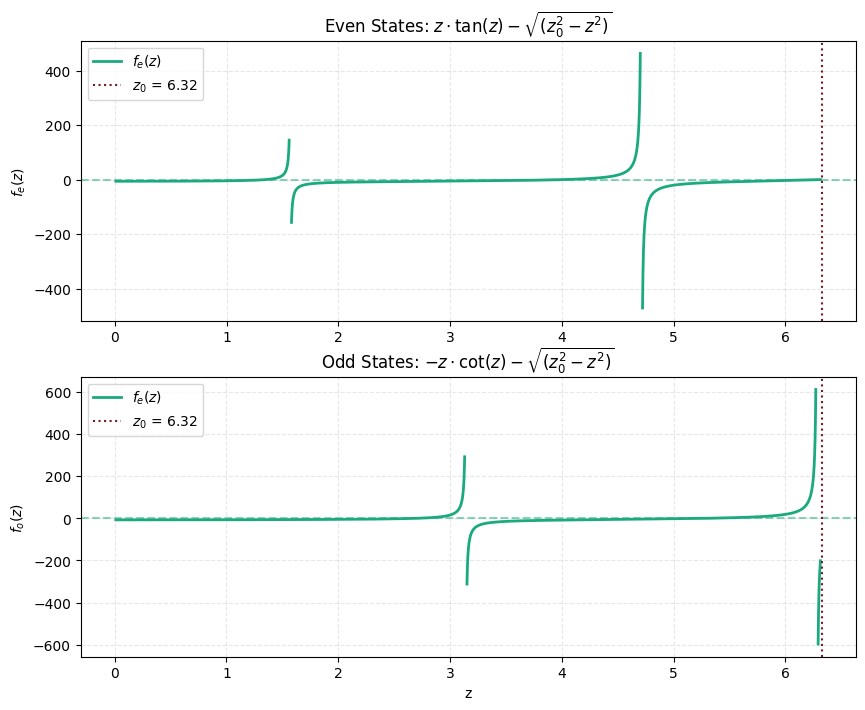

<Axes: title={'center': 'Odd States: $-z \\cdot \\cot(z) - \\sqrt{(z_0^2 - z^2)}$'}, xlabel='z', ylabel='$f_o(z)$'>

In [220]:
#   Excersice 1: PLOTTING
# ====================================================================================

# Parameters/Konstants
h_bar = 1
m = 1
a = 1
V_0 = 20

# Calculate z_0
z_0 = a * np.sqrt(2 * m * V_0 / h_bar**2)
print(f"z0 = {z_0:.2f}")
# print(z_0/np.pi + 1)
print(fr"Expected bound states: \approx {int(z_0/np.pi) + 1}")

# Define the functions 
def f_even(z_val):
    return z_val * np.tan(z_val) - np.sqrt(z_0**2 - z_val**2)

def f_odd(z_val):
    return -z_val / np.tan(z_val) - np.sqrt(z_0**2 - z_val**2)

# Create z array, avoiding singularities at z = pi/2, pi, 3pi/2, ... (halve Multiples of pi)
z_val = np.linspace(0.01, z_0 - 0.01, 10000)

# Handle singularities by masking
mask_even = np.abs(np.cos(z_val)) > 0.01  # tan(z) goes to infty when cos(z) \approx 0
mask_odd = np.abs(np.sin(z_val)) > 0.01   # cot(z) goes to infty when sin(z) \approx 0

# Plot
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# Cutting the function, thus the vertical liens disapeare
f_even_fixed = np.where(mask_even, f_even(z_val), np.nan)

ax[0].plot(
    z_val,
    f_even_fixed, 
    linewidth=2, 
    label='$f_e(z)$'
    )


# Line at 0
ax[0].axhline(y=0, linestyle='--', alpha=0.5)

# Line marking z_0
ax[0].axvline(x=z_0, linestyle=':', label=f'$z_0$ = {z_0:.2f}', color=pap.Colors.WINE_RED)

ax[0].set_ylabel('$f_e(z)$')
ax[0].set_title(r'Even States: $z \cdot \tan(z) - \sqrt{(z_0^2 - z^2)}$')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Cutting the function, thus the vertical liens disapeare
f_odd_fixed = np.where(mask_odd, f_odd(z_val), np.nan)

ax[1].plot(
    z_val,
    f_odd_fixed, 
    linewidth=2, 
    label='$f_e(z)$'
    )

ax[1].axhline(y=0, linestyle='--', alpha=0.5)
ax[1].axvline(x=z_0, linestyle=':', label=fr'$z_0$ = {z_0:.2f}', color=pap.Colors.WINE_RED)
ax[1].set_xlabel('z')
ax[1].set_ylabel('$f_o(z)$')
ax[1].set_title(r'Odd States: $-z \cdot \cot(z) - \sqrt{(z_0^2 - z^2)}$')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

# # Fokus on Roots (visualising vertical lines that should be abolished)
# ax[0].set_ylim(-1,1)
# ax[1].set_ylim(-1,1)
# ax[1].set_xlim(2,3)

pap.plot_me()

Looking at the roots we see that all roots should be of multiplicity 1, since the function is somoot between the singulrities (peaks of tan/cotan), the slop at (around) the root point is $\not = 0$ and around the corssings there is no degenerate distribution (the function is continuous around the roots.)

<hr>

In [221]:
# Helper functions
def estimateIntervall(val:float, abw:float=10):
    '''
    Gets an estimated root and a percentage value to get quicker the intervall

    Params
    -----
        val : estimated root position
        abw : percentage of how big the intervall should be around val
    '''
    diff = val * abw / 100
    return val - diff, val + diff

def calc_z_0(V_0:int = 20):
    return a * np.sqrt(2 * m * V_0 / h_bar**2)

In [222]:
# Defining functions in sympy
z_0 = calc_z_0(20)
z = sp.symbols('z')

func_even = z * sp.tan(z) - sp.sqrt(z_0**2 - z**2)
func_odd = -z / sp.tan(z) - sp.sqrt(z_0**2 - z**2)

## Exercise 2: Root Finding
Implement the following methods: (5 pt.)
+ bisection
+ Newton method
+ secant method

Use all of them to compute one selected root. For each method measure and comment
on (3 pt.)
+ number of iterations
+ runtime
+ final residual

In [233]:
def root_bi_section(function:sp, a:float, b:float, data = None, tolerance: float = 1e-4, max_iterations:int = 5000):
    '''
    Method to find the root of a given Functin between a given intervall [a,b].

    Params
    -----
        func : function to be analysed (sympy). Must be one dimensionl (one parameter!)
        params : Parameter of the function
            must be phrased as an array
        data : Values for the parameters
            must be phrased as an array
        a : smaller (left) limit of intervall
        b : bigger (right) limit of intervall
        tolarance : How cloase the result should get
        max_iterations : exit crit 

    Returns
    ----
        p : approximated position of root
        log : information of the algorithm (iterations, searching intervall of current, p of current iteration, f(p) of current iteration, error of current iteration, time of the current iteration and totoal time until current iteration)
        total_time : time needed to approximate root

    Raises
    ----
        ValueError : If the function does not depend on exactly one free symbol.
        RuntimeError : If the function deos not converges to an value within the while loop (given iterations)
    '''
    # Check number of free symbols
    free_vars = function.free_symbols
    if len(free_vars) != 1:
        raise ValueError(f"The function must depend on exactly one variable. Found {len(free_vars)}: {free_vars}")
    
    # Get the single variable
    var = list(free_vars)[0]  

    # Lambdify functions
    f = sp.lambdify(var, function, "numpy")

    # Calcualate initial values 
    fa = f(a)
    fb = f(b)

    if fa * fb > 0:
        raise ValueError('The initial contition that f(a) times f(b) > 0  is not satisfied')
        # return None, None, None

    # Saving information of every Iteration 
    log = {
        'iteration': [],
        'a': [],
        'b': [],
        'p': [],
        'f_p': [],
        'error': [],
        'time_step': [], # Time for one iteration
        'cumulative_time': [] # total time
    }

    start_total_time = time.perf_counter()
    cumulative_time = 0.0

    # define recursive function to get closer and closer to the root
    i = 0
    while i < max_iterations:
        iter_start = time.perf_counter()
        # calculate the arethmetic mean of a and b and its value
        p = (a+b)/2
        fp = f(p)

        # Calculate error (width of the interval)
        error = (b - a) / 2


        # Store current iteration data
        log['iteration'].append(i)
        log['a'].append(a)
        log['b'].append(b)
        log['p'].append(p)
        log['f_p'].append(fp)
        log['error'].append(error)

        if abs(fp) < tolerance or (b-a)/2 < tolerance:
            return p, log, total_time

        # check if either a or b must turn p
        if fa * fp < 0:
            b = p
            fb = fp
        else:
            a = p
            fa = fp

        i = i + 1
        
        iter_end = time.perf_counter()
        step_duration = iter_end - iter_start
        cumulative_time += step_duration

        # Time logging
        log['time_step'].append(step_duration)
        log['cumulative_time'].append(cumulative_time)

        total_time = time.perf_counter() - start_total_time

    raise RuntimeError("Bisection method did not converge within the maximum number of iterations.")


In [224]:
def root_by_newt(func:sp, p_0: float, tolerance: float = 1e-4, max_iterations: int = 1000):
    '''
    Approximate a root using the Newton-Raphson Method.
    
    Params
    ------
        func : A SymPy expression representing a function of one variable.
        p_0 : Initial guess.
        tolerance : Convergence tolerance.
        max_iterations : Maximum number of iterations.
        
    Returns
    ------
        p : approximatd root abscissa (x-Value)
        log : information of the algorithm (iterations, searching intervall of current, p of current iteration, f(p) of current iteration, error of current iteration, time of the current iteration and totoal time until current iteration)
        total_time : time needed to approximate root

    Raises
    ------
        ValueError : If the function does not depend on exactly one free symbol.
        RuntimeError : If the function deos not converges to an value within the while loop (given iterations)
    '''
    # Check number of free symbols
    free_vars = func.free_symbols
    if len(free_vars) != 1:
        raise ValueError(f"The function must depend on exactly one variable. Found {len(free_vars)}: {free_vars}")
    
    # Get the single variable
    var = list(free_vars)[0]  
    
    # Compute derivative
    func_prime = sp.diff(func, var)
        
    # Saving information of every Iteration 
    log = {
        'iteration': [],
        'p': [],
        'f_p': [],
        'f_prime_p': [], # Value of f'(p)
        'error': [],
        'time_step': [], # Time for one iteration
        'cumulative_time': [] # total time
    }

    start_total_time = time.perf_counter()
    cumulative_time = 0.0

    # Newton-Raphson iteration
    p = p_0
    i = 0
    while i < max_iterations:
        iter_start = time.perf_counter()
        f_p_val = func.subs(var, p)
        fp_p_val = func_prime.subs(var, p)
        
        if fp_p_val == 0:
            raise ZeroDivisionError("Derivative is zero; Newton's method fails.")
        
        p_new = p - f_p_val / fp_p_val
        if abs(p_new - p) < tolerance:
            return float(p_new), log, total_time
        
        # Add information in log
        log['iteration'].append(i)
        log['p'].append(p_new)
        log['f_p'].append(f_p_val)
        log['f_prime_p'].append(fp_p_val)

        p = p_new
        i = i + 1

        iter_end = time.perf_counter()
        step_duration = iter_end - iter_start
        cumulative_time += step_duration

        log['time_step'].append(step_duration)
        log['cumulative_time'].append(cumulative_time)

        total_time = time.perf_counter() - start_total_time

    raise RuntimeError("Newton's method did not converge within the maximum number of iterations.")

In [225]:
def root_by_secant(func:sp, x_0:float, x_1:float, tolerance:float = 1e-12, max_iterations:int = 1000):
    '''
    Method to approximate the root of an given function by using the secant method.

    Params
    ------
        func : A SymPy expression representing a function of one variable.
        x_0 : first point for secant
        x_1 : second point for secant
        tolerance : Convergence tolerance.
        max_iterations : Maximum number of iterations.

    Returns
    ------
        p : approximatd root abscissa (x-Value)
        log : information of the algorithm (iterations, searching intervall of current, p of current iteration, f(p) of current iteration, error of current iteration, time of the current iteration and totoal time until current iteration)
        total_time : time needed to approximate root

    Raises
    ------
        ValueError : If the function does not depend on exactly one free symbol.
        RuntimeError : If the function deos not converges to an value within the while loop (given iterations)
    '''

    # Check number of free symbols
    free_vars = func.free_symbols
    if len(free_vars) != 1:
        raise ValueError(f"The function must depend on exactly one variable. Found {len(free_vars)}: {free_vars}")
    
    # Get the single variable
    var = list(free_vars)[0]  

    # Lambdify functions
    f = sp.lambdify(var, func, "numpy")

    # Saving information of every Iteration 
    log = {
        'iteration': [],
        'p': [],
        'x_0': [],
        'x_1': [],
        'error': [],
        'time_step': [], # Time for one iteration
        'cumulative_time': [] # total time
    }

    start_total_time = time.perf_counter()
    cumulative_time = 0.0

    # Starting conditions
    x_n0 = x_0 
    x_n1 = x_1
    i = 0
    # Starting the iteration
    while i < max_iterations:
        iter_start = time.perf_counter()

        # Calculation new x value 
        new_x = x_n1 - f(x_n1) * (x_n1 - x_n0)/(f(x_n1) - f(x_n0))

        # Log information
        log['iteration'].append(i)
        log['p'].append(new_x)
        log['x_0'].append(x_n0)
        log['x_1'].append(x_n1)

        # Set new conditions
        x_n0 = x_n1
        x_n1 = new_x

        if abs(x_n0 - x_n1) < tolerance:
            return x_n1, log, total_time
        
        i = i + 1

        iter_end = time.perf_counter()
        step_duration = iter_end - iter_start
        cumulative_time += step_duration

        # Logging times
        log['time_step'].append(step_duration)
        log['cumulative_time'].append(cumulative_time)

        total_time = time.perf_counter() - start_total_time

    raise RuntimeError("Bisection method did not converge within the maximum number of iterations.")

### Example of bisection

In [226]:
intervall = estimateIntervall(1.35, 10)

a = intervall[0]
b = intervall[1]
tol = 1e-15 # Why does it brak after e-15  -> Single Float limit

print(f'Intervall is set to: I = [{intervall[0]:.4f}, {intervall[1]:.4f}]')
root_e, log_e, timer_e = root_bi_section(func_even, a, b)

print(f'The root is (approximately) at: x = {root_e:.5f}')
print(f'Iterationen: {len(log_e['iteration'])}\nCalculation Time: {timer_e:.3g}s')

print('=========================')

intervall = estimateIntervall(2.7, 10)

a = intervall[0]
b = intervall[1]
tol = 1e-15

print(f'Intervall is set to: I = [{intervall[0]:.4f}, {intervall[1]:.4f}]')
root, log, timer = root_bi_section(func_odd, a, b)

print(f'The root is (approximately) at: x = {root:.5f}')
print(f'Iterationen: {len(log['iteration'])}\nCalculation Time: {timer:.3g}s')

Intervall is set to: I = [1.2150, 1.4850]
-2.9372057780811454 11.118197744138637
The root is (approximately) at: x = 1.35494
Iterationen: 12
Calculation Time: 7.2e-05s
Intervall is set to: I = [2.4300, 2.9700]
-3.021061923441672 11.554397327318256
The root is (approximately) at: x = 2.70046
Iterationen: 13
Calculation Time: 6.81e-05s


C:\Users\finnz\AppData\Local\Temp\ipykernel_16792\124577259.py:18: RuntimeWarning: invalid value encountered in sqrt
  return z_val * np.tan(z_val) - np.sqrt(z_0**2 - z_val**2)


(1.3413944091796877, 1.3684932861328125)

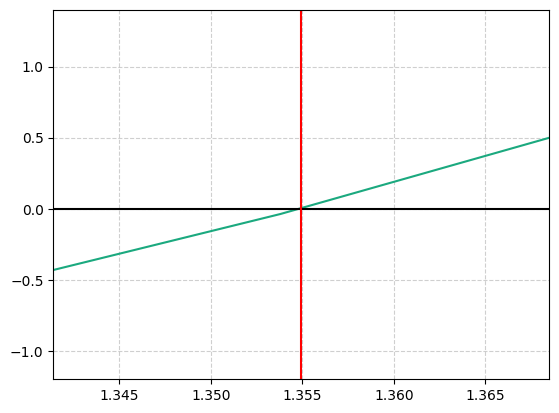

In [227]:
p = np.linspace(0, calc_z_0(20), 1000)
plt.plot(p, f_even(p))
plt.hlines(0, 0, z_0, 'black')
plt.vlines(root_e, 10, -10, 'red')
plt.ylim(-1.2,1.4)
lo = estimateIntervall(root_e, 1)
plt.xlim(lo[0], lo[1])
# plt.xlim(1,2)


Question: Why do my computers get different results for the root.

### Example of Newton method

In [228]:
print(fr'For the even function we search for a root')
root, log, timer = root_by_newt(func_even, 1.35) 
print(fr'Root found at {root:.4f}')
print(fr'with a totoal of {len(log['iteration'])} iterations')
print(fr'and a calculation time of {timer:.3g}s')

print('=========================')

print(fr'For the odd function we search for a root')
root, log, timer = root_by_newt(func_odd, 2.7) 
print(fr'Root found at {root:.4f}')
print(fr'with a totoal of {len(log['iteration'])} iterations')
print(fr'and a calculation time of {timer:.3g}s')

For the even function we search for a root
Root found at 1.3549
with a totoal of 2 iterations
and a calculation time of 0.00255s
For the odd function we search for a root
Root found at 2.7004
with a totoal of 1 iterations
and a calculation time of 0.000993s


## Example of Secant

In [229]:
intervall = estimateIntervall(1.35, 10)
print(fr'For the even function we search for a root in I = [{intervall[0], intervall[1]}]')
root, log, timer = root_by_secant(func_even, intervall[0], intervall[1])
print(fr'Root found at {root:.4f}')
print(fr'with a totoal of {len(log['iteration'])} iterations')
print(fr'and a calculation time of {timer:.3g}s')

print('=========================')

intervall = estimateIntervall(2.7, 0.0001)
print(fr'For the even function we search for a rood in I = [{intervall[0], intervall[1]}]')
root_odd, log, timer = root_by_secant(func_odd, intervall[0], intervall[1])
print(fr'root found at {root_odd:.4f}')
print(fr'with a totoal of {len(log['iteration'])} iterations')
print(fr'and a calculation time of {timer:.3g}s')

For the even function we search for a root in I = [(1.215, 1.485)]
Root found at 1.3549
with a totoal of 9 iterations
and a calculation time of 0.000131s
For the even function we search for a rood in I = [(2.6999973, 2.7000027)]
root found at 2.7004
with a totoal of 4 iterations
and a calculation time of 5.76e-05s


<hr>

## Exercise 3: Automatic Detection of All Roots (7 pt.)
Construct an automated algorithm that finds all roots of $f_e(z) = 0$ and $f_o(z) = 0$ in
the interval $0 < z < z_0$. Split the interval in a clever way. Compute all bound-state
energies. Why is the parity-separated formulation numerically useful?

In [230]:
def calc_multiplcity(func:sp, root:float, tolerance:float=1e-4, safety_limit:int=100):
    '''
    Calculates the multiplicity of a root of a given one-dimensional function.

    Params
    -----------
    func : sympy expression
        The one dimensional function to analyze
    root_val : float or sympy number
        The specific root value to check
    tol : float
        Tolerance for zero comparison
    safety_limit : int 
        maximum possible multiplicity of function
    
    Returns
    --------
    int : Multiplicity of the root, or None if not a root
    '''
    
    # Check number of free symbols
    free_vars = func.free_symbols
    if len(free_vars) != 1:
        raise ValueError(f"The function must depend on exactly one variable. Found {len(free_vars)}: {free_vars}")
    
    # Get the single variable
    var = list(free_vars)[0] 
    
    # Check if given root is actually a root
    if np.abs(func.subs(var, root)) > tolerance:
        return None

    derivative = func
    multiplcity = 0
    while True:
        # Calculate value of derivertive of root value
        d_root_val = derivative.subs(var, root)
        
        if np.abs(d_root_val) > tol:
            return multiplcity

        multiplcity = multiplcity + 1
        derivative = sp.diff(derivative, var)

        if multiplcity == safety_limit:
            raise ValueError("Maximum multiplicity exceeded.")    

In [231]:
def find_root_intervalls(func:sp, intervall_start:float, intervall_end:float, division_size:float=0.25, critical_value:float=5, tolerance:float=1e-4):
    '''
    Estimates intervalls where root are very likely to be, by checking sign changes all over the plot. Also tries to estimate possible local extrama (multiplicity of > 0).

    Params
    -----------
    func : sympy expression
        The one dimensional function to analyze
    intervall_start : float
        Start of the intervall to check for roots
    intervall_end : float
        End of the intervall to check for roots
    division_size : float
        How big the steps should be to check for sign changes.
    critical_value : float
        Only sign changes where the function values are smaller than this value are considered as root intervalls. This is to avoid intervalls where the function just changes its sign but does not get close to zero (e.g. at singularities).

    Retunrs
    -----------
    sing_change_intervall : List of estimated intervalls where roots are likely to be. Each tuple contains the start and end of the intervall.
    possible_mulitplicity_root : List of estimated intervall where roots might just be of higher multiplicity.
    '''

    # Check number of free symbols
    free_vars = func.free_symbols
    if len(free_vars) != 1:
        raise ValueError(f"The function must depend on exactly one variable. Found {len(free_vars)}: {free_vars}")
    
    # Get the single variable
    var = list(free_vars)[0] 

    x_values = np.arange(intervall_start, intervall_end, division_size)
    f_values = np.array([func.subs(var, x) for x in x_values], dtype=np.float64)

    sing_change_intervall = []
    possible_mulitplicity_root = []
    # Estimating by looking for sign changes
    for p, val in enumerate(f_values[:-1]):
        if (f_values[p] * f_values[p+1] < 0) and (np.abs(f_values[p]) < critical_value or np.abs(f_values[p+1]) < critical_value):
            # print(f'found sign change between\n f({x_values[p]:.2f})={f_values[p]} and\n f({x_values[p+1]:.2f})={f_values[p+1]}\n and all absolut function values are smaller than {critical_value}')
            sing_change_intervall.append((x_values[p], x_values[p+1]))
        elif np.abs(f_values[p]) * np.abs(f_values[p+1]) < tolerance:
            possible_mulitplicity_root.append((x_values[p], x_values[p+1]))

    return sing_change_intervall, possible_mulitplicity_root

inter = find_root_intervalls(func_odd, 0, z_0, 0.05)
print(inter[0])

[(np.float64(2.7), np.float64(2.75)), (np.float64(5.25), np.float64(5.300000000000001))]


In [ ]:
def calc_roots(func:sp, intervall_start:float, intervall_end:float, division_size:float=0.25, critical_value:float=5, tolerance:float=1e-4, max_iterations:int = 1000):
    '''
    Approximates roots of a given one dimensional function.

    Params
    -----------
    func : sympy expression
        The one dimensional function to analyze
    intervall_start : float
        Start of the intervall to check for roots
    intervall_end : float
        End of the intervall to check for roots
    division_size : float
        How big the steps should be to check for sign changes.
    critical_value : float
        Only sign changes where the function values are smaller than this value are considered as root intervalls. This is to avoid intervalls where the function just changes its sign but does not get close to zero (e.g. at singularities).

    Retunrs
    -----------
    roots : List of approximated roots.
        1. Secant
        2. Newton
        3. Bisection
    '''

    root_intervalls = find_root_intervalls(func, intervall_start, intervall_end, division_size, critical_value, tolerance)

    roots_secant = []
    for i, val in enumerate(root_intervalls):
        r = root_by_secant(func, root_intervalls[0][i][0], root_intervalls[0][i][1], tolerance=tolerance, max_iterations=max_iterations)
        roots_secant.append(r[0])

    roots_newton = []
    for i, val in enumerate(root_intervalls):
        r = root_by_newt(func, np.mean(root_intervalls[0][i]), tolerance=tolerance, max_iterations=max_iterations)
        roots_newton.append(r[0])

    roots_bisection = []
    for i, val in enumerate(root_intervalls):
        r = root_bi_section(func, root_intervalls[0][i][0], root_intervalls[0][i][1], tolerance=tolerance, max_iterations=max_iterations)
        roots_bisection.append(r[0])

    
    return roots_secant, roots_newton, roots_bisection

([np.float64(2.7004397124828285), np.float64(5.291910861788999)],
 [2.7004446997817735, 5.291910861564826],
 [np.float64(2.70048828125), np.float64(5.291894531250001)])

<hr>

## Exercise 4: Speed vs Accuracy (3 pt.)
For one root compare the methods for tolerances
$$10^{−4}, 10^{−8}, 10^{−12}.$$
Create:
+ a table of iterations and runtime
+ a plot of runtime vs residual
+ a short discussion

In [ ]:
tol = [1e-4, 1e-8, 1e-12]

iterations = []
runtimes = []


 **Method**    | **Iterations** | **Runtime** | **Avg Error** 
---------------|----------------|-------------|---------------
 **Newton**    |                |             |               
 **Bisection** |                |             |               
 **Secant**    |                |             |               



<hr>

## Exercise 5: Dependence on Well Depth (optional 3 pt.)
Repeat the analysis for
$$V_0 = 5, 10, 20, 50.$$
Comment on the number of bound states and on the behaviour of the roots with
increasing $V_0$ (location/slope). What happens for $V_0 \to \infty$? Comment on the accuracy
of a root $z$ for a given stopping criterion based on the value of $f(z) (|f (z)| < \epsilon)$.

<hr>